In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/24pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,0.395002
2014-07-04 12:00:00,0.570041,0.388721
2014-07-04 13:00:00,0.405458,0.276204
2014-07-04 14:00:00,0.405458,0.206635
2014-07-04 15:00:00,0.427403,0.111717


In [3]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/24pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,0.346151
2014-07-04 12:00:00,0.570041,0.408717
2014-07-04 13:00:00,0.405458,0.284443
2014-07-04 14:00:00,0.405458,0.198529
2014-07-04 15:00:00,0.427403,0.077927


In [4]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/24pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,-0.019504
2014-07-04 12:00:00,0.570041,-0.018861
2014-07-04 13:00:00,0.405458,-0.003001
2014-07-04 14:00:00,0.405458,-0.073371
2014-07-04 15:00:00,0.427403,-0.154869


In [5]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.009063
2014-07-04 22:00:00,0.559069,0.219173
2014-07-04 23:00:00,0.613930,0.344451
2014-07-05 00:00:00,0.745596,0.561541
2014-07-05 01:00:00,0.789484,0.531499


In [6]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2014-12-01 22:40:00,0.789484,0.855610
2014-12-01 22:50:00,0.559069,0.856116
2014-12-01 23:00:00,0.613930,0.992877
2014-12-01 23:10:00,0.745596,0.993342
2014-12-01 23:20:00,0.789484,0.813371


In [7]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-06-30 07:00:00,-0.219955,-0.321420
2014-06-30 08:00:00,-0.384538,-0.283980
2014-06-30 09:00:00,-0.428427,-0.281666
2014-06-30 10:00:00,-0.395510,-0.280251
2014-06-30 11:00:00,-0.318705,-0.277759


In [8]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])



In [9]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-06-30 07:00:00,NaN,NaN,NaN,NaN,NaN,0.101465
2014-06-30 08:00:00,NaN,NaN,NaN,NaN,NaN,-0.100558
2014-06-30 09:00:00,NaN,NaN,NaN,NaN,NaN,-0.146761
2014-06-30 10:00:00,NaN,NaN,NaN,NaN,NaN,-0.115259
2014-06-30 11:00:00,NaN,NaN,NaN,NaN,NaN,-0.040946


In [10]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-12-01 23:00:00,-0.528491,-0.538256,-0.606483,-0.711676,-0.378947,-0.513370
2014-12-02 00:00:00,-0.477426,-0.467695,-0.582279,-0.657270,-0.227370,-0.436786
2014-12-02 01:00:00,-0.471580,-0.471558,-0.614414,-0.679121,-0.833389,-0.479958
2014-12-02 02:00:00,-0.418627,-0.428949,-0.551453,-0.625092,-0.235956,-0.457836
2014-12-02 03:00:00,-0.440164,-0.420126,-0.555060,-0.619921,0.929919,-0.479332


Muestra aleatoria

In [11]:
final = final.sample(frac=0.10, random_state=42)

In [12]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [13]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


5.788749223296077e-07


In [14]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


3.0490422982101595e-08


In [15]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


4.6982866858538596e-07


In [16]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


4.683844885177272e-10


In [17]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


0.15585460389253572


In [18]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


6.202542017113703e-08


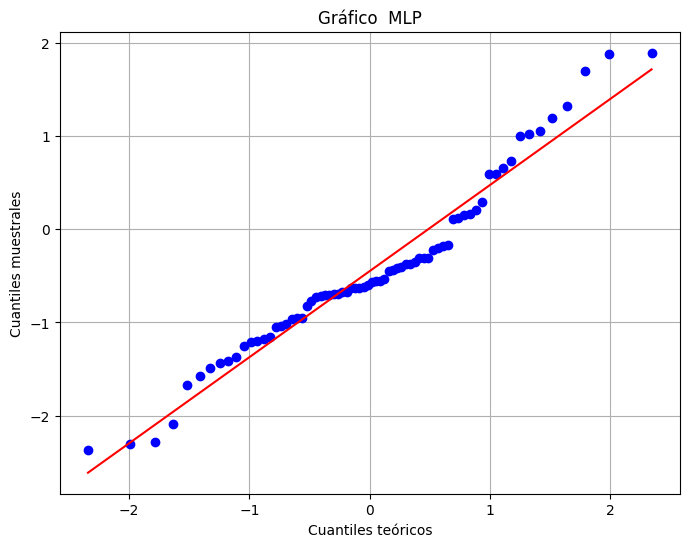

In [19]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico  MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

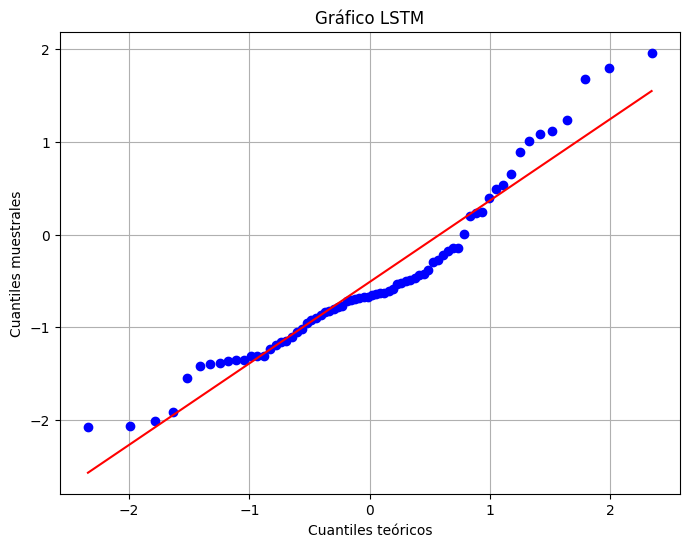

In [20]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

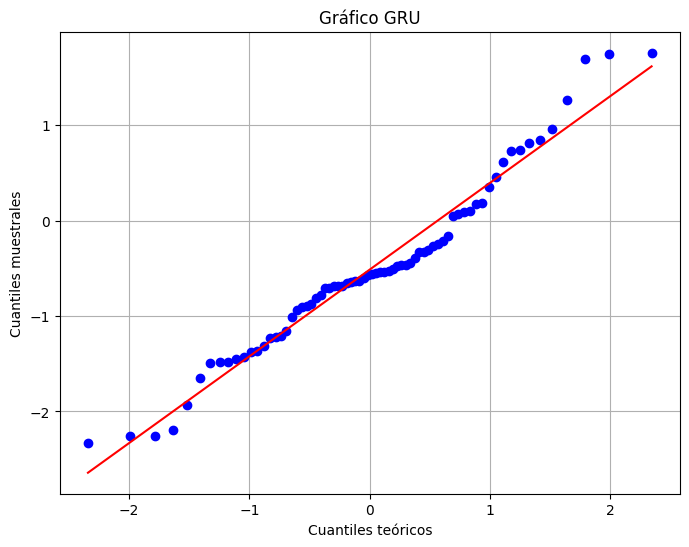

In [21]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

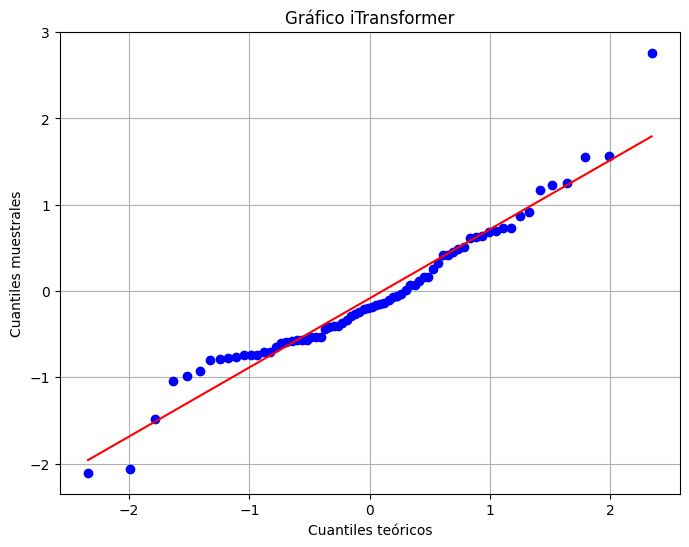

In [22]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

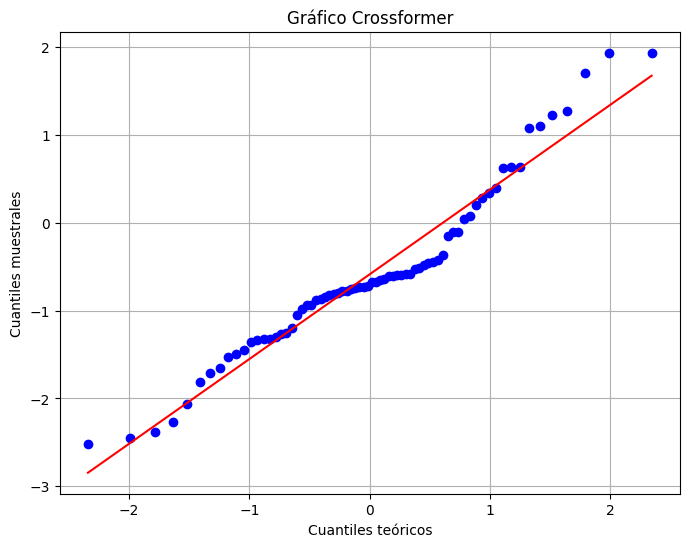

In [23]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

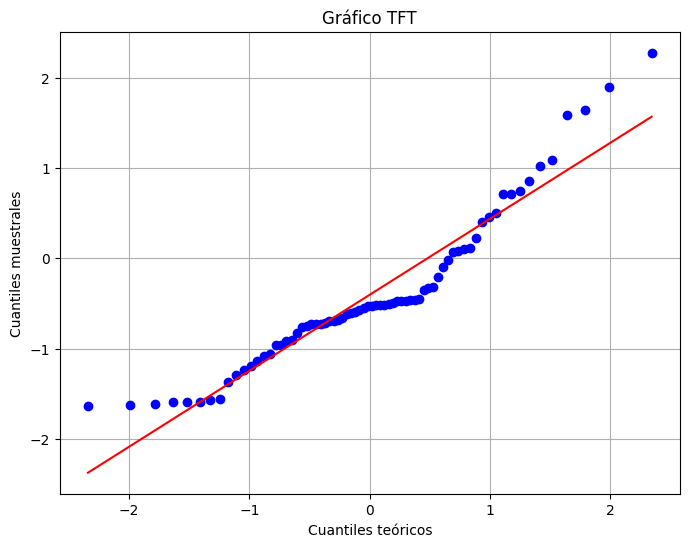

In [24]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [25]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

3.1639784868908983e-09


In [26]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00045,0.00679,0.00543
1,MLP vs GRU,0.00051,0.00770,0.00565
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.01333,0.19999,0.06666
4,MLP vs TFT,0.30445,1.00000,0.60890
5,LSTM vs GRU,0.77903,1.00000,0.77903
6,LSTM vs Crossformer,0.00294,0.04406,0.02350
7,LSTM vs iTransformer,0.00414,0.06204,0.02895
8,LSTM vs TFT,0.00116,0.01736,0.01157
9,GRU vs Crossformer,0.00020,0.00298,0.00258
